# IDXExchange real-estate predictive modeling project

In [218]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
import statsmodels.formula.api as smf
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from xgboost import XGBRegressor

# Step 1: Data Cleaning

In [219]:
file_paths = [
    "CRMLSSold202412.csv",
    "CRMLSSold202501_filled.csv",
    "CRMLSSold202502.csv",
    "CRMLSSold202503.csv",
    "CRMLSSold202504.csv",
    "CRMLSSold202505.csv"
    
]

dfs = [pd.read_csv(path) for path in file_paths]

combined_df = pd.concat(dfs, axis=0, ignore_index=True)

combined_df = combined_df.loc[:, combined_df.columns[:100]]

combined_df.to_csv("combined_output.csv", index=False)

print(" Combined CSV saved as 'combined_output.csv'")

 Combined CSV saved as 'combined_output.csv'


We started by comibining all 6 datasets, into one big megadataset, the code for that is shown above

In [220]:
df = pd.read_csv("combined_output.csv")
df

C:\Users\sunsu\AppData\Local\Temp\ipykernel_6904\1033202321.py:1: DtypeWarning: Columns (78,79) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("combined_output.csv")


,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,latfilled,lonfilled
0,Glendale,Glendale,NaN,NaN,NaN,NaN,NaN,3350000.0,552665323,Listings@LockerRealty.com,...,NaN,False,0.0,NaN,91331,NaN,88445.0,NaN,NaN,NaN
1,InlandValleys,InlandValleys,NaN,True,NaN,NaN,NaN,125000.0,551977092,Patriciapandeyrealtor@gmail.com,...,NaN,False,NaN,NaN,92530,0.0,9148.0,NaN,NaN,NaN
2,PacificWest,PacificWest,NaN,True,NaN,NaN,NaN,300000.0,551927931,joshuacho1004@gmail.com,...,NaN,False,NaN,NaN,92356,0.0,6969600.0,NaN,NaN,NaN
3,Mlslistings,Mlslistings,"Carpet,Laminate,Tile",False,NaN,NaN,NaN,800000.0,544420694,assistant@danmoskowitz.com,...,NaN,False,0.0,Other,95122,NaN,6418.0,NaN,NaN,NaN
4,LakeCounty,LakeCounty,NaN,True,NaN,NaN,NaN,21500.0,516603298,jan@zapcom.net,...,NaN,False,NaN,NaN,95464,0.0,4559.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125537,HighDesert,HighDesert,NaN,True,NaN,NaN,NaN,2990000.0,1014021520,kim.hdrealtysource@hotmail.com,...,NaN,False,NaN,NaN,92345,NaN,6969600.0,NaN,NaN,NaN
125538,SanDiego,SanDiego,"Carpet,Laminate,Tile",True,NaN,NaN,False,3295.0,1013198225,calrealestatedoctor@gmail.com,...,NaN,NaN,2.0,NaN,92078,0.0,NaN,NaN,NaN,NaN
125539,NorthSanDiegoCounty,NorthSanDiegoCounty,Wood,True,NaN,NaN,False,5000.0,1008327642,MikeJonesSanDiegoRealtor@Gmail.com,...,NaN,NaN,1.0,Encinitas Union,92024,NaN,1.0,NaN,NaN,NaN
125540,Oakland,Oakland,NaN,NaN,NaN,NaN,NaN,700.0,1002448236,mike@hugheyhomes.com,...,NaN,NaN,NaN,NaN,94803,0.0,0.0,NaN,NaN,NaN


Above is the dataset before cleaning has occured

In [221]:
with pd.option_context('display.max_rows', None):
    print(df.isna().sum())
df.isna().sum() 

BuyerAgentAOR                       45
ListAgentAOR                        45
Flooring                         52107
ViewYN                           12323
WaterfrontYN                    125454
BasementYN                      123491
PoolPrivateYN                    15351
OriginalListPrice                  389
ListingKey                           0
ListAgentEmail                     454
CloseDate                            0
ClosePrice                           3
ListAgentFirstName                 667
ListAgentLastName                   17
Latitude                            20
Longitude                           16
UnparsedAddress                    206
PropertyType                         0
LivingArea                        9191
ListPrice                          208
DaysOnMarket                         0
ListOfficeName                       0
BuyerOfficeName                   1478
CoListOfficeName                 99492
ListAgentFullName                   14
CoListAgentFirstName     

BuyerAgentAOR                       45
ListAgentAOR                        45
Flooring                         52107
ViewYN                           12323
WaterfrontYN                    125454
                                 ...  
AssociationFee                   38798
LotSizeSquareFeet                11102
MiddleOrJuniorSchoolDistrict    125542
latfilled                       106804
lonfilled                       106804
Length: 80, dtype: int64

Above shows us the number of NA values per columns

In [222]:
fdf = df[[
    "ViewYN",
    "PoolPrivateYN",
    "LivingArea",
    "CountyOrParish",
    "PropertySubType",
    "PropertyType",
    "LotSizeSquareFeet",
    "YearBuilt",
    "BathroomsTotalInteger",
    "BedroomsTotal",
    "GarageSpaces",
    "ClosePrice",
    "NewConstructionYN",
    "Levels",
    "ParkingTotal",
    "FireplaceYN"
    
]]
fdf

,ViewYN,PoolPrivateYN,LivingArea,CountyOrParish,PropertySubType,PropertyType,LotSizeSquareFeet,YearBuilt,BathroomsTotalInteger,BedroomsTotal,GarageSpaces,ClosePrice,NewConstructionYN,Levels,ParkingTotal,FireplaceYN
0,NaN,NaN,NaN,Los Angeles,NaN,Land,88445.0,NaN,0.0,NaN,0.0,2100000.0,False,NaN,0.0,NaN
1,True,NaN,NaN,Riverside,NaN,Land,9148.0,NaN,NaN,NaN,NaN,125000.0,False,NaN,NaN,NaN
2,True,NaN,NaN,San Bernardino,NaN,Land,6969600.0,NaN,NaN,NaN,NaN,135000.0,False,NaN,NaN,NaN
3,False,NaN,1151.0,Santa Clara,SingleFamilyResidence,Residential,6418.0,1979.0,6.0,8.0,0.0,1120000.0,False,NaN,0.0,True
4,True,NaN,NaN,Lake,NaN,Land,4559.0,NaN,NaN,NaN,NaN,4000.0,False,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125537,True,NaN,NaN,San Bernardino,NaN,Land,6969600.0,NaN,NaN,NaN,NaN,4000000.0,False,NaN,NaN,NaN
125538,True,False,1229.0,San Diego,SingleFamilyResidence,ResidentialLease,NaN,2020.0,3.0,2.0,2.0,3395.0,NaN,Two,4.0,True
125539,True,False,956.0,San Diego,Condominium,ResidentialLease,1.0,2010.0,1.0,1.0,1.0,5500.0,NaN,One,1.0,False
125540,NaN,NaN,NaN,Contra Costa,NaN,CommercialSale,0.0,NaN,0.0,NaN,NaN,400.0,NaN,NaN,0.0,NaN


Above is the first part to cleaning the dataset. We initially started off with 80 rows but we trimmed it down to 16, this was done by manually inspecting rows, and removing rows that either had too many NA values, or seemed to have no impact on "ClosePrice" whatsoever. For example "Flooring" in theory is a vraible that could potentially have an impact on the "ClosePrice", however it has 50,000+ NA values, which is almost 40% of the dataset gone. Another example is the variable "ListAgentAOR". List agent first of all does not seem to be an indicator of a houses sale price, secondly there are simple too many list agents for it to have a positive affect on the model

In [223]:
fdf.isna().sum() 

ViewYN                   12323
PoolPrivateYN            15351
LivingArea                9191
CountyOrParish               0
PropertySubType           9956
PropertyType                 0
LotSizeSquareFeet        11102
YearBuilt                 5629
BathroomsTotalInteger     5990
BedroomsTotal             8655
GarageSpaces             16850
ClosePrice                   3
NewConstructionYN        14939
Levels                   16824
ParkingTotal              4031
FireplaceYN              11241
dtype: int64

Above is the NA values after reducing columsn from 80 to 16

In [224]:
fdf = fdf.dropna().reset_index(drop=True)
fdf.shape[0]

72489

Above is the resulting rows after dropping NA values for the 16 columns, we are left with little over half the rows we started with

In [225]:
fdf

,ViewYN,PoolPrivateYN,LivingArea,CountyOrParish,PropertySubType,PropertyType,LotSizeSquareFeet,YearBuilt,BathroomsTotalInteger,BedroomsTotal,GarageSpaces,ClosePrice,NewConstructionYN,Levels,ParkingTotal,FireplaceYN
0,True,False,1434.0,Los Angeles,SingleFamilyResidence,Residential,6473.0,1940.0,1.0,3.0,1.0,890000.0,False,One,1.0,True
1,False,False,2872.0,San Diego,SingleFamilyResidence,Residential,5219.0,2001.0,3.0,5.0,3.0,1138000.0,False,Two,6.0,True
2,True,False,2824.0,Riverside,SingleFamilyResidence,Residential,7000.0,2024.0,3.0,5.0,2.0,681877.0,True,Two,2.0,False
3,True,False,2500.0,Los Angeles,SingleFamilyResidence,Residential,8336.0,1971.0,3.0,5.0,2.0,900000.0,False,Two,2.0,True
4,False,False,2363.0,Los Angeles,SingleFamilyResidence,Residential,11705.0,1995.0,3.0,5.0,2.0,862000.0,False,Two,2.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72484,False,False,1014.0,Los Angeles,SingleFamilyResidence,Residential,4225.0,1926.0,1.0,2.0,1.0,510000.0,False,One,1.0,False
72485,False,False,500.0,Orange,Duplex,ResidentialLease,10500.0,1961.0,1.0,0.0,0.0,2350.0,False,One,0.0,False
72486,True,False,1142.0,Riverside,Condominium,Residential,1307.0,1977.0,2.0,2.0,1.0,250000.0,False,One,1.0,False
72487,True,False,1550.0,Orange,SingleFamilyResidence,ResidentialLease,4995.0,1953.0,2.0,3.0,0.0,4500.0,False,One,2.0,True


Above is the first step to a usable dataframe

In [226]:
fdf.dtypes

ViewYN                    object
PoolPrivateYN             object
LivingArea               float64
CountyOrParish            object
PropertySubType           object
PropertyType              object
LotSizeSquareFeet        float64
YearBuilt                float64
BathroomsTotalInteger    float64
BedroomsTotal            float64
GarageSpaces             float64
ClosePrice               float64
NewConstructionYN         object
Levels                    object
ParkingTotal             float64
FireplaceYN               object
dtype: object

Above is code to make sure there are no more implicit NA values 

In [227]:
view_counts = fdf["ViewYN"].value_counts()
view_counts

ViewYN
True     46305
False    26184
Name: count, dtype: int64

In [228]:
pool_counts = fdf["PoolPrivateYN"].value_counts()
pool_counts

PoolPrivateYN
False    62254
True     10235
Name: count, dtype: int64

In [229]:
counts = fdf["CountyOrParish"].value_counts()
counts

x = counts[counts >= 30]
top_pub_counts = x.index
top_pub_counts
fdf = fdf[fdf['CountyOrParish'].isin(top_pub_counts)]
fdf.shape[0]

counts = fdf["CountyOrParish"].value_counts()
counts

CountyOrParish
Los Angeles        24126
Orange             13745
Riverside          12629
San Bernardino      9269
San Diego           5137
San Luis Obispo     1182
Ventura             1066
Butte                770
Contra Costa         756
Kern                 715
Alameda              611
Merced               462
Lake                 388
Santa Barbara        323
Fresno               273
Madera               247
Tehama                85
Glenn                 75
Stanislaus            63
Mariposa              63
Tulare                59
Santa Clara           47
Imperial              46
Kings                 38
Solano                34
Yuba                  31
Name: count, dtype: int64

In [230]:
#PropertySubType	PropertyType City		NewConstructionYN	Levels
counts = fdf["PropertySubType"].value_counts()
counts


x = counts[counts >= 11000]
top_pub_counts = x.index
top_pub_counts
fdf = fdf[fdf['PropertySubType'].isin(top_pub_counts)]
fdf.shape[0]

counts = fdf["PropertySubType"].value_counts()
counts

PropertySubType
SingleFamilyResidence    52422
Name: count, dtype: int64

In [231]:
counts = fdf["PropertyType"].value_counts()
counts


x = counts[counts >= 19000]
top_pub_counts = x.index
top_pub_counts
fdf = fdf[fdf['PropertyType'].isin(top_pub_counts)]
fdf.shape[0]

counts = fdf["PropertyType"].value_counts()
counts

PropertyType
Residential    42587
Name: count, dtype: int64

In [232]:
counts = fdf["NewConstructionYN"].value_counts()
counts

NewConstructionYN
False    40477
True      2110
Name: count, dtype: int64

In [233]:
counts = fdf["Levels"].value_counts()
counts

x = counts[counts >= 256]
top_pub_counts = x.index
top_pub_counts
fdf = fdf[fdf['Levels'].isin(top_pub_counts)]
fdf.shape[0]

counts = fdf["Levels"].value_counts()
counts

Levels
One            26866
Two            14170
ThreeOrMore      859
MultiSplit       409
Name: count, dtype: int64

The code above was used to get rid of rows that may have had only 1 variable type. For example the variable "Levels" initially had a type called "FourOrMore" but only one row had that, when breaking up data into train and testing datasets, this will cause issues so we went ahead and removed all types that where not atleast 256 other rows. This same process was done for all other variables, however the number of rows critieria changed depending on variable

In [234]:
# Dataset for models that do not require linear regression

#df_orig = fdf

Linear regression models are very succeseptible to outliers, however others models are not. To deal with this, when working on new models, we will use df_orig and not fdf

<Axes: xlabel='LivingArea', ylabel='ClosePrice'>

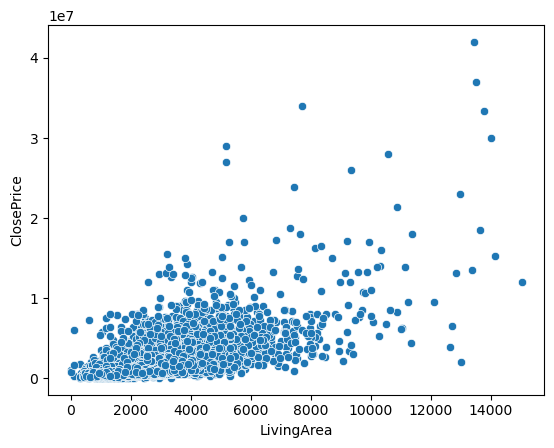

In [235]:
fdf = fdf[fdf['ClosePrice'] < 8e7]
fdf = fdf[fdf['LivingArea'] < 16000]

sns.scatterplot(x = "LivingArea", y= "ClosePrice", data = fdf)

<Axes: xlabel='LotSizeSquareFeet', ylabel='ClosePrice'>

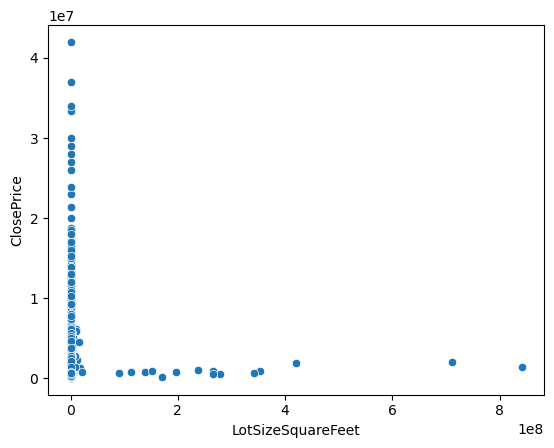

In [236]:
#LotSizeSquareFeet	YearBuilt	BathroomsTotalInteger BedroomsTotal	GarageSpaces	ClosePrice		ParkingTotal
fdf = fdf[fdf['LotSizeSquareFeet'] < 1.5e9]
sns.scatterplot(x = "LotSizeSquareFeet", y= "ClosePrice", data = fdf)

<Axes: xlabel='YearBuilt', ylabel='ClosePrice'>

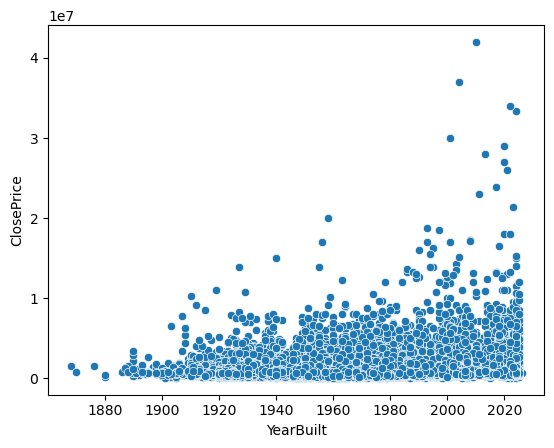

In [237]:
# #		YearBuilt	BathroomsTotalInteger BedroomsTotal	GarageSpaces	ClosePrice		ParkingTotal
fdf = fdf[fdf['YearBuilt'] > 1801]
sns.scatterplot(x = "YearBuilt", y= "ClosePrice", data = fdf)

<Axes: xlabel='BathroomsTotalInteger', ylabel='ClosePrice'>

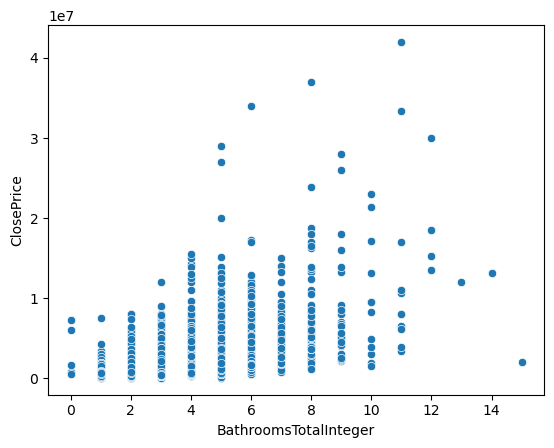

In [238]:
# #		BathroomsTotalInteger BedroomsTotal	GarageSpaces	ClosePrice		ParkingTotal
fdf = fdf[fdf['BathroomsTotalInteger'] < 20]
sns.scatterplot(x = "BathroomsTotalInteger", y= "ClosePrice", data = fdf)

<Axes: xlabel='BedroomsTotal', ylabel='ClosePrice'>

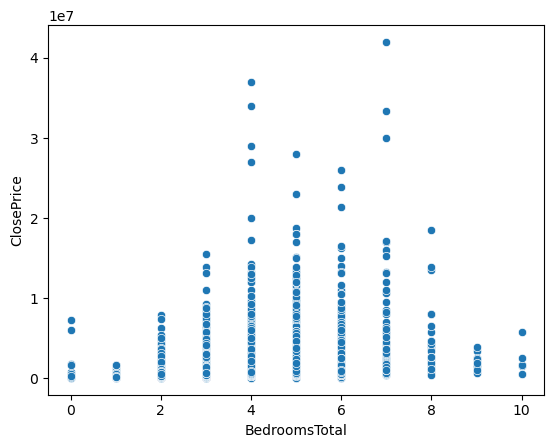

In [239]:
# #	 BedroomsTotal	GarageSpaces	ClosePrice		ParkingTotal
fdf = fdf[fdf['BedroomsTotal'] < 15]
sns.scatterplot(x = "BedroomsTotal", y= "ClosePrice", data = fdf)

<Axes: xlabel='BedroomsTotal', ylabel='ClosePrice'>

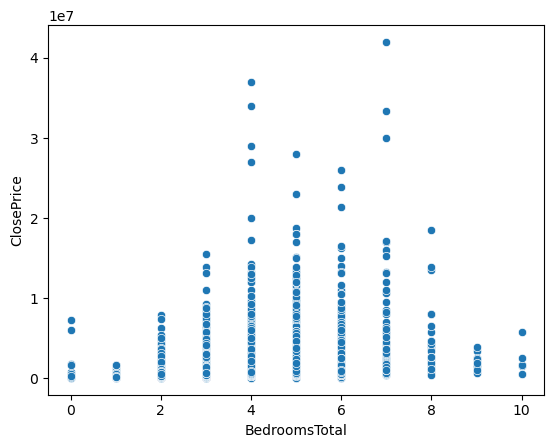

In [240]:
 #		 BedroomsTotal	GarageSpaces	ClosePrice		ParkingTotal
sns.scatterplot(x = "BedroomsTotal", y= "ClosePrice", data = fdf)

<Axes: xlabel='GarageSpaces', ylabel='ClosePrice'>

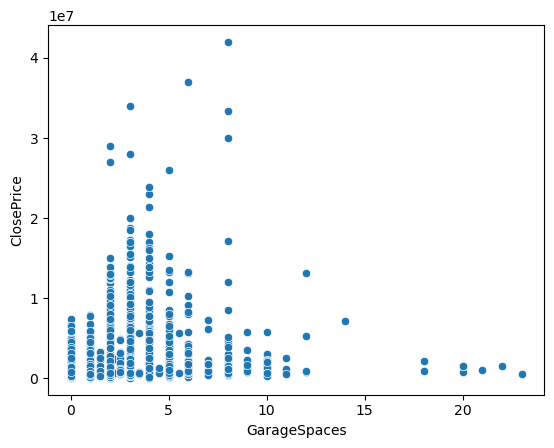

In [241]:
# #			GarageSpaces	ClosePrice		ParkingTotal
fdf = fdf[fdf['GarageSpaces'] < 150]
sns.scatterplot(x = "GarageSpaces", y= "ClosePrice", data = fdf)

<Axes: xlabel='ParkingTotal', ylabel='ClosePrice'>

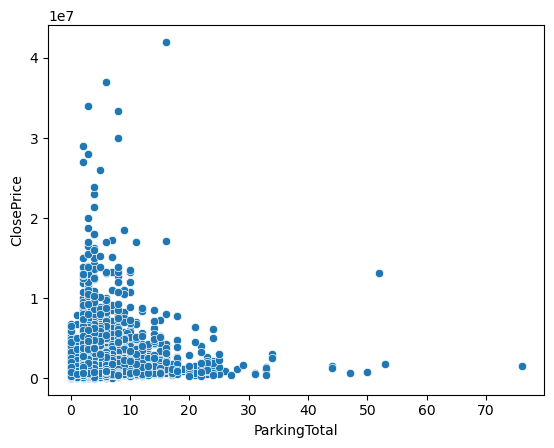

In [242]:
# #			ClosePrice		ParkingTotal
fdf = fdf[fdf['ParkingTotal'] < 100]
sns.scatterplot(x = "ParkingTotal", y= "ClosePrice", data = fdf)

In [243]:
df_orig = fdf

Same thing that was done for the categorical variables, will be done to the numerical variables, variables that seemes to high where removed to preserve the usability of a linear regression model

In [244]:
fdf.shape[0]

42288

# Step 2 Pre-Processing Data

Above is the number of rows left after cleaning the data

In [245]:
fdf.corr(numeric_only=True)

,LivingArea,LotSizeSquareFeet,YearBuilt,BathroomsTotalInteger,BedroomsTotal,GarageSpaces,ClosePrice,ParkingTotal
LivingArea,1.000000,-0.003183,0.392600,0.851383,0.661565,0.476382,0.624819,0.305426
LotSizeSquareFeet,-0.003183,1.000000,0.004002,-0.001548,-0.004698,0.000455,0.001161,0.001513
YearBuilt,0.392600,0.004002,1.000000,0.419600,0.285227,0.368845,0.051560,0.158299
BathroomsTotalInteger,0.851383,-0.001548,0.419600,1.000000,0.647296,0.404691,0.566324,0.262978
BedroomsTotal,0.661565,-0.004698,0.285227,0.647296,1.000000,0.350870,0.318407,0.201804
GarageSpaces,0.476382,0.000455,0.368845,0.404691,0.350870,1.000000,0.231484,0.469769
ClosePrice,0.624819,0.001161,0.051560,0.566324,0.318407,0.231484,1.000000,0.176088
ParkingTotal,0.305426,0.001513,0.158299,0.262978,0.201804,0.469769,0.176088,1.000000


As we can see above, there is multicollinearity, so we have to use LASSO, RIDGE or ELASTIC NET to help us with this issue

In [246]:
#numerical_cols = ['LivingArea', 'LotSizeSquareFeet', 'YearBuilt', 'BathroomTotalInteger','BedroomsTotal','GarageSpaces','ClosePrice','ParkingTotal']
#categorical_cols = ['ViewYN', 'PoolPrivateYN', 'CountyOrParish', 'PropertySubType', 'PropertyType', 'City', 'NewConstructionYN', 'Levels', 'FireplaceYN']  

#for x1 in numerical_cols:
    #for x2 in categorical_cols:
        #sns.lmplot(x=x1, y='ClosePrice', hue=x2, data=fdf, ci=False)
        #plt.show()

Ignore above 

In [247]:
from sklearn.preprocessing import StandardScaler


Scaler_training = StandardScaler()
scaled_expl_vars_test = Scaler_training.fit_transform(fdf[['LivingArea', 'LotSizeSquareFeet', 'YearBuilt', 'BathroomsTotalInteger','BedroomsTotal','GarageSpaces','ClosePrice','ParkingTotal']])


fdf[['LivingArea', 'LotSizeSquareFeet', 'YearBuilt', 'BathroomTotalInteger','BedroomsTotal','GarageSpaces','ClosePrice','ParkingTotal']] = scaled_expl_vars_test
fdf.head()

,ViewYN,PoolPrivateYN,LivingArea,CountyOrParish,PropertySubType,PropertyType,LotSizeSquareFeet,YearBuilt,BathroomsTotalInteger,BedroomsTotal,GarageSpaces,ClosePrice,NewConstructionYN,Levels,ParkingTotal,FireplaceYN,BathroomTotalInteger
0,True,False,-0.601292,Los Angeles,SingleFamilyResidence,Residential,-0.018575,-1.425697,1.0,-0.502383,-1.097641,-0.184644,False,One,-0.818941,True,-1.49509
1,False,False,0.877755,San Diego,SingleFamilyResidence,Residential,-0.018752,0.837034,3.0,1.623264,1.076332,0.030817,False,Two,1.482345,True,0.37316
2,True,False,0.828384,Riverside,SingleFamilyResidence,Residential,-0.018500,1.690195,3.0,1.623264,-0.010654,-0.365460,True,Two,-0.358683,False,0.37316
3,True,False,0.495136,Los Angeles,SingleFamilyResidence,Residential,-0.018311,-0.275785,3.0,1.623264,-0.010654,-0.175956,False,Two,-0.358683,True,0.37316
4,False,False,0.354226,Los Angeles,SingleFamilyResidence,Residential,-0.017834,0.614470,3.0,1.623264,-0.010654,-0.208970,False,Two,-0.358683,True,0.37316


In [248]:
#from sklearn.preprocessing import StandardScaler


#Scaler_training = StandardScaler()
#scaled_expl_vars_test = Scaler_training.fit_transform(df_orig[['LivingArea', 'LotSizeSquareFeet', 'YearBuilt', 'BathroomsTotalInteger','BedroomsTotal','GarageSpaces','ClosePrice','ParkingTotal']])


#df_orig[['LivingArea', 'LotSizeSquareFeet', 'YearBuilt', 'BathroomTotalInteger','BedroomsTotal','GarageSpaces','ClosePrice','ParkingTotal']] = scaled_expl_vars_test
#df_orig.head()

In order for findings to be interpretable we have Z-scored all variables

In [249]:
categorical_df = fdf[['ViewYN', 'PoolPrivateYN', 'CountyOrParish', 'PropertySubType', 'PropertyType', 'NewConstructionYN', 'Levels', 'FireplaceYN']]
categorical_df
indicator_df = pd.get_dummies(categorical_df, drop_first=True, dtype=int)
indicator_df
fdf = fdf.drop(columns=categorical_df.columns)
fdf = pd.concat([fdf, indicator_df], axis=1)
fdf

,LivingArea,LotSizeSquareFeet,YearBuilt,BathroomsTotalInteger,BedroomsTotal,GarageSpaces,ClosePrice,ParkingTotal,BathroomTotalInteger,ViewYN_True,...,CountyOrParish_Stanislaus,CountyOrParish_Tehama,CountyOrParish_Tulare,CountyOrParish_Ventura,CountyOrParish_Yuba,NewConstructionYN_True,Levels_One,Levels_ThreeOrMore,Levels_Two,FireplaceYN_True
0,-0.601292,-0.018575,-1.425697,1.0,-0.502383,-1.097641,-0.184644,-0.818941,-1.495090,1,...,0,0,0,0,0,0,1,0,0,1
1,0.877755,-0.018752,0.837034,3.0,1.623264,1.076332,0.030817,1.482345,0.373160,0,...,0,0,0,0,0,0,0,0,1,1
2,0.828384,-0.018500,1.690195,3.0,1.623264,-0.010654,-0.365460,-0.358683,0.373160,1,...,0,0,0,0,0,1,0,0,1,0
3,0.495136,-0.018311,-0.275785,3.0,1.623264,-0.010654,-0.175956,-0.358683,0.373160,1,...,0,0,0,0,0,0,0,0,1,1
4,0.354226,-0.017834,0.614470,3.0,1.623264,-0.010654,-0.208970,-0.358683,0.373160,0,...,0,0,0,0,0,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72481,-0.733974,-0.018505,-0.609630,1.0,-1.565207,-2.184628,-0.727639,-1.279198,-1.495090,0,...,0,0,0,0,0,0,1,0,0,0
72482,-0.153875,0.011349,1.653101,2.0,-0.502383,-0.010654,0.215001,-0.358683,-0.560965,1,...,0,0,0,0,0,1,1,0,0,1
72483,-0.213530,-0.017641,0.317719,2.0,0.560440,-2.184628,-0.300193,-1.279198,-0.560965,1,...,0,0,0,0,0,0,0,0,1,1
72484,-1.033280,-0.018893,-1.945013,1.0,-1.565207,-1.097641,-0.514785,-0.818941,-1.495090,0,...,0,0,0,0,0,0,1,0,0,0


In [250]:
categorical_df = df_orig[['ViewYN', 'PoolPrivateYN', 'CountyOrParish', 'PropertySubType', 'PropertyType', 'NewConstructionYN', 'Levels', 'FireplaceYN']]
categorical_df
indicator_df = pd.get_dummies(categorical_df, drop_first=True, dtype=int)
indicator_df
df_orig = df_orig.drop(columns=categorical_df.columns)
df_orig = pd.concat([df_orig, indicator_df], axis=1)
df_orig

,LivingArea,LotSizeSquareFeet,YearBuilt,BathroomsTotalInteger,BedroomsTotal,GarageSpaces,ClosePrice,ParkingTotal,BathroomTotalInteger,ViewYN_True,...,CountyOrParish_Stanislaus,CountyOrParish_Tehama,CountyOrParish_Tulare,CountyOrParish_Ventura,CountyOrParish_Yuba,NewConstructionYN_True,Levels_One,Levels_ThreeOrMore,Levels_Two,FireplaceYN_True
0,-0.601292,-0.018575,-1.425697,1.0,-0.502383,-1.097641,-0.184644,-0.818941,-1.495090,1,...,0,0,0,0,0,0,1,0,0,1
1,0.877755,-0.018752,0.837034,3.0,1.623264,1.076332,0.030817,1.482345,0.373160,0,...,0,0,0,0,0,0,0,0,1,1
2,0.828384,-0.018500,1.690195,3.0,1.623264,-0.010654,-0.365460,-0.358683,0.373160,1,...,0,0,0,0,0,1,0,0,1,0
3,0.495136,-0.018311,-0.275785,3.0,1.623264,-0.010654,-0.175956,-0.358683,0.373160,1,...,0,0,0,0,0,0,0,0,1,1
4,0.354226,-0.017834,0.614470,3.0,1.623264,-0.010654,-0.208970,-0.358683,0.373160,0,...,0,0,0,0,0,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72481,-0.733974,-0.018505,-0.609630,1.0,-1.565207,-2.184628,-0.727639,-1.279198,-1.495090,0,...,0,0,0,0,0,0,1,0,0,0
72482,-0.153875,0.011349,1.653101,2.0,-0.502383,-0.010654,0.215001,-0.358683,-0.560965,1,...,0,0,0,0,0,1,1,0,0,1
72483,-0.213530,-0.017641,0.317719,2.0,0.560440,-2.184628,-0.300193,-1.279198,-0.560965,1,...,0,0,0,0,0,0,0,0,1,1
72484,-1.033280,-0.018893,-1.945013,1.0,-1.565207,-1.097641,-0.514785,-0.818941,-1.495090,0,...,0,0,0,0,0,0,1,0,0,0


Above is the resulting dataframe after Z-score standardization

# Step 3 Machine Learning

In [251]:
from sklearn.model_selection import train_test_split
df_train, df_test = train_test_split(fdf, test_size = 0.20, random_state = 207)

Splitting data into train test split

In [252]:
feature_train = df_train.drop(['ClosePrice'], axis=1)
feature_train.head()

,LivingArea,LotSizeSquareFeet,YearBuilt,BathroomsTotalInteger,BedroomsTotal,GarageSpaces,ParkingTotal,BathroomTotalInteger,ViewYN_True,PoolPrivateYN_True,...,CountyOrParish_Stanislaus,CountyOrParish_Tehama,CountyOrParish_Tulare,CountyOrParish_Ventura,CountyOrParish_Yuba,NewConstructionYN_True,Levels_One,Levels_ThreeOrMore,Levels_Two,FireplaceYN_True
37071,-0.652719,-0.018429,-0.275785,2.0,-0.502383,-0.010654,-0.358683,-0.560965,0,0,...,0,0,0,0,0,0,1,0,0,1
72348,-0.821400,-0.018320,-0.016127,2.0,-0.502383,-0.010654,-0.358683,-0.560965,1,0,...,0,0,0,0,0,0,1,0,0,1
49816,-0.744259,-0.017901,-1.166040,2.0,0.560440,-2.184628,-1.279198,-0.560965,1,0,...,0,0,0,0,0,0,1,0,0,0
30363,0.167031,-0.018581,-1.166040,3.0,0.560440,-1.097641,-0.818941,0.373160,1,0,...,0,0,0,0,0,1,1,0,0,1
7521,-0.531351,-0.007987,0.911222,3.0,-0.502383,-0.010654,-0.358683,0.373160,0,0,...,0,0,0,0,0,0,0,0,1,1


In [253]:
feature_test = df_test.drop(['ClosePrice'], axis=1)
feature_test.head()

,LivingArea,LotSizeSquareFeet,YearBuilt,BathroomsTotalInteger,BedroomsTotal,GarageSpaces,ParkingTotal,BathroomTotalInteger,ViewYN_True,PoolPrivateYN_True,...,CountyOrParish_Stanislaus,CountyOrParish_Tehama,CountyOrParish_Tulare,CountyOrParish_Ventura,CountyOrParish_Yuba,NewConstructionYN_True,Levels_One,Levels_ThreeOrMore,Levels_Two,FireplaceYN_True
44781,-0.695918,-0.018728,-1.166040,2.0,-0.502383,-0.010654,-0.358683,-0.560965,0,0,...,0,0,0,0,0,0,1,0,0,0
9324,0.506450,-0.018443,0.911222,3.0,2.686088,-0.010654,-0.358683,0.373160,1,0,...,0,0,0,0,0,0,0,0,1,1
54252,-0.724717,-0.018891,-1.945013,2.0,0.560440,-0.010654,-0.358683,-0.560965,0,0,...,0,0,0,0,0,0,1,0,0,0
40383,0.597991,-0.019138,1.022504,4.0,-0.502383,-0.010654,0.561831,1.307284,1,0,...,0,0,0,0,0,0,0,1,0,1
48473,-0.630091,-0.018713,0.280625,2.0,-0.502383,-0.010654,-0.358683,-0.560965,1,0,...,0,0,0,0,0,0,1,0,0,1


In [254]:
target_train = df_train["ClosePrice"]
target_train


37071   -0.089077
72348   -0.519129
49816   -0.536505
30363    0.387022
7521    -0.336683
           ...   
13571    0.579894
68927   -0.427037
67695   -0.667953
21408    0.493015
35638   -0.214183
Name: ClosePrice, Length: 33830, dtype: float64

In [255]:
target_test = df_test["ClosePrice"]
target_test

44781   -0.493065
9324    -0.376647
54252   -0.306318
40383    1.062074
48473    0.215001
           ...   
6627    -0.314963
53678   -0.089077
1426     0.779716
70716   -0.349714
16820    1.830956
Name: ClosePrice, Length: 8458, dtype: float64

In [256]:
# import statsmodels.api as sm
# import matplotlib.pyplot as plt
# X_with_const = sm.add_constant(feature_test)
# target_test = np.log1p(target_test)
# model = sm.OLS(target_test, X_with_const).fit()

# plt.scatter(model.fittedvalues, model.resid)
# plt.axhline(y=0, color='r', linestyle='--')  
# plt.xlabel('Fitted values') 
# plt.ylabel('Residuals')
# plt.title('Residual Plot')
# plt.show()

ignore above

In [257]:
from sklearn.linear_model import LinearRegression

lin_reg_mod = LinearRegression()

0.4182204792693398


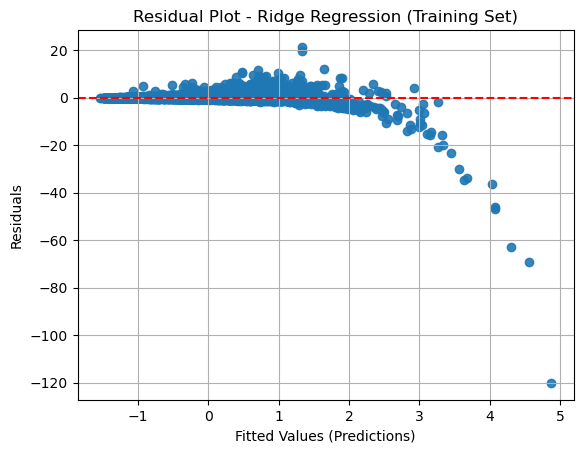

In [258]:
target_train_log = np.log1p(target_train)

ridge = Ridge(alpha=0.895, max_iter = 1000)
ridge.fit(feature_train, target_train_log)

preds_log = ridge.predict(feature_train)
preds_log1 = ridge.score(feature_train, target_train)
print(preds_log1)
preds_real = np.expm1(preds_log) 

residuals = target_train - preds_real

plt.scatter(preds_log, residuals, alpha=0.895)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Fitted Values (Predictions)')
plt.ylabel('Residuals')
plt.title('Residual Plot - Ridge Regression (Training Set)')
plt.grid(True)
plt.show()

In [259]:
import numpy as np
from sklearn.linear_model import Ridge, Lasso
data = []
for i in np.arange(0,0.9,0.005):
    lin_reg_mod = Ridge(alpha=i, max_iter=1000)
    lin_reg_mod.fit(feature_train, target_train)
    x = lin_reg_mod.score(feature_test, target_test)
    data.append([i, x])
df_rsqrR = pd.DataFrame(data, columns=['lambda', 'test_r2'])
df_rsqrR


,lambda,test_r2
0,0.000,0.510198
1,0.005,0.510187
2,0.010,0.510187
3,0.015,0.510188
4,0.020,0.510188
...,...,...
175,0.875,0.510222
176,0.880,0.510222
177,0.885,0.510222
178,0.890,0.510222


In [260]:
df_rsqrR.nlargest(1,"test_r2")

,lambda,test_r2
179,0.895,0.510223


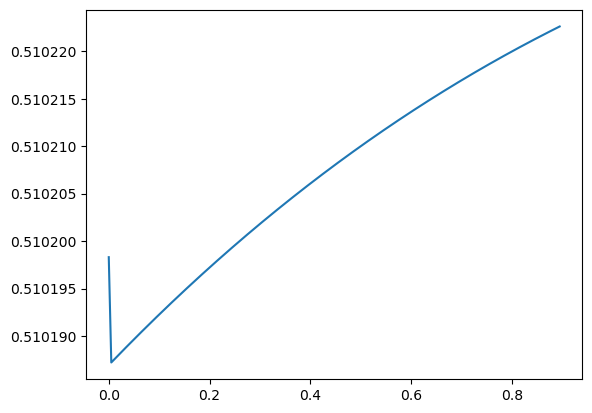

In [261]:
plt.plot(df_rsqrR['lambda'].values, df_rsqrR['test_r2'].values)

In [262]:
import numpy as np
from sklearn.linear_model import Ridge, Lasso
data = []
for i in np.arange(0,0.9,0.005):
    lin_reg_mod = Lasso(alpha=i, max_iter=1000)
    lin_reg_mod.fit(feature_train, target_train)
    x = lin_reg_mod.score(feature_test, target_test)
    data.append([i, x])
df_rsqrL = pd.DataFrame(data, columns=['lambda', 'test_r2'])
df_rsqrL


c:\Users\sunsu\anaconda3\Lib\site-packages\sklearn\base.py:1474: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
c:\Users\sunsu\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
c:\Users\sunsu\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.918e+03, tolerance: 3.181e+00 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinat

,lambda,test_r2
0,0.000,0.510187
1,0.005,0.497075
2,0.010,0.491604
3,0.015,0.484508
4,0.020,0.475762
...,...,...
175,0.875,-0.000116
176,0.880,-0.000116
177,0.885,-0.000116
178,0.890,-0.000116


In [263]:
df_rsqrL.nlargest(1,'test_r2')

,lambda,test_r2
0,0.0,0.510187


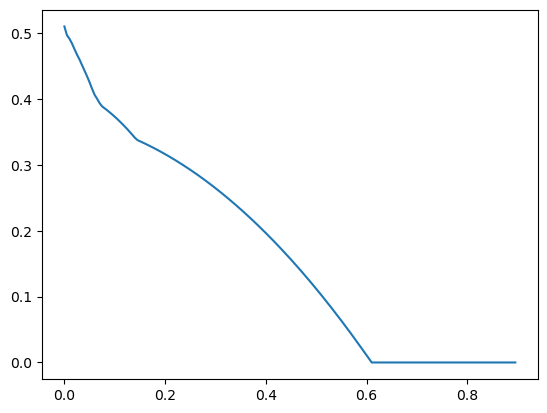

In [264]:
plt.plot(df_rsqrL['lambda'].values, df_rsqrL['test_r2'].values)

In [265]:
data = []
for alpha_val in np.arange(0.001, 0.9, 0.005):
    model = ElasticNet(alpha=alpha_val, l1_ratio=0.2, max_iter=10000)
    model.fit(feature_train, target_train)
    test_r2 = model.score(feature_test, target_test)
    data.append([alpha_val, test_r2])

# Convert to DataFrame
df_rsqrE = pd.DataFrame(data, columns=['alpha', 'test_r2'])
df_rsqrE

,alpha,test_r2
0,0.001,0.508787
1,0.006,0.504001
2,0.011,0.499363
3,0.016,0.495491
4,0.021,0.492016
...,...,...
175,0.876,0.265781
176,0.881,0.265149
177,0.886,0.264516
178,0.891,0.263883


In [266]:
df_rsqrE.nlargest(1,"test_r2")

,alpha,test_r2
0,0.001,0.508787


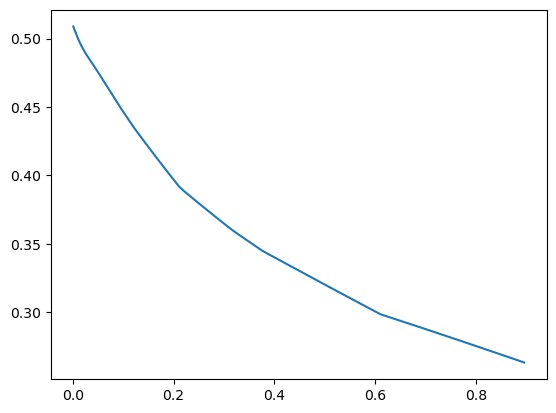

In [267]:
plt.plot(df_rsqrE['alpha'].values, df_rsqrE['test_r2'].values)

In [268]:
from sklearn.model_selection import KFold
crossval = KFold(n_splits=5, shuffle=True, random_state=437)
crossval

data = []
for i in np.arange(0,0.51,0.01):
    ridge1 = Ridge(alpha=i, max_iter=1000)
    test_fold_r2 = cross_val_score(ridge1, feature_train, target_train, cv=crossval, scoring="r2")
    data.append([i, test_fold_r2, test_fold_r2.mean()])
df_ptune = pd.DataFrame(data, columns=['lambda', 'rsqrs', 'mean_rsqr'])
df_ptune


c:\Users\sunsu\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=6.73485e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\sunsu\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=2.60485e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\sunsu\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=1.08037e-16): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


,lambda,rsqrs,mean_rsqr
0,0.00,"[0.5425190633318786, 0.5989347458715581, 0.575...",0.564314
1,0.01,"[0.5425190677532437, 0.5989346882144397, 0.575...",0.564315
2,0.02,"[0.5425190680378299, 0.5989346267281914, 0.575...",0.564315
3,0.03,"[0.5425190642124815, 0.5989345614390391, 0.575...",0.564316
4,0.04,"[0.5425190563038609, 0.5989344923730204, 0.575...",0.564316
5,0.05,"[0.5425190443384496, 0.5989344195559843, 0.575...",0.564316
6,0.06,"[0.5425190283425495, 0.5989343430135933, 0.575...",0.564316
7,0.07,"[0.5425190083422846, 0.5989342627713254, 0.575...",0.564317
8,0.08,"[0.5425189843636022, 0.5989341788544746, 0.575...",0.564317
9,0.09,"[0.5425189564322743, 0.5989340912881538, 0.575...",0.564317


In [269]:
df_ptune.nlargest(1,'mean_rsqr')

,lambda,rsqrs,mean_rsqr
50,0.5,"[0.5425147038165983, 0.5989276458170367, 0.575...",0.564324


### Starting Random Forest Regression

In [270]:
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import train_test_split
df_train_rf, df_test_rf = train_test_split(df_orig, test_size = 0.20, random_state = 207)


In [271]:
feature_train_rf = df_train_rf.drop(['ClosePrice'], axis=1)
feature_train_rf.head()

,LivingArea,LotSizeSquareFeet,YearBuilt,BathroomsTotalInteger,BedroomsTotal,GarageSpaces,ParkingTotal,BathroomTotalInteger,ViewYN_True,PoolPrivateYN_True,...,CountyOrParish_Stanislaus,CountyOrParish_Tehama,CountyOrParish_Tulare,CountyOrParish_Ventura,CountyOrParish_Yuba,NewConstructionYN_True,Levels_One,Levels_ThreeOrMore,Levels_Two,FireplaceYN_True
37071,-0.652719,-0.018429,-0.275785,2.0,-0.502383,-0.010654,-0.358683,-0.560965,0,0,...,0,0,0,0,0,0,1,0,0,1
72348,-0.821400,-0.018320,-0.016127,2.0,-0.502383,-0.010654,-0.358683,-0.560965,1,0,...,0,0,0,0,0,0,1,0,0,1
49816,-0.744259,-0.017901,-1.166040,2.0,0.560440,-2.184628,-1.279198,-0.560965,1,0,...,0,0,0,0,0,0,1,0,0,0
30363,0.167031,-0.018581,-1.166040,3.0,0.560440,-1.097641,-0.818941,0.373160,1,0,...,0,0,0,0,0,1,1,0,0,1
7521,-0.531351,-0.007987,0.911222,3.0,-0.502383,-0.010654,-0.358683,0.373160,0,0,...,0,0,0,0,0,0,0,0,1,1


In [272]:
feature_test_rf = df_test_rf.drop(['ClosePrice'], axis=1)
feature_test_rf.head()

,LivingArea,LotSizeSquareFeet,YearBuilt,BathroomsTotalInteger,BedroomsTotal,GarageSpaces,ParkingTotal,BathroomTotalInteger,ViewYN_True,PoolPrivateYN_True,...,CountyOrParish_Stanislaus,CountyOrParish_Tehama,CountyOrParish_Tulare,CountyOrParish_Ventura,CountyOrParish_Yuba,NewConstructionYN_True,Levels_One,Levels_ThreeOrMore,Levels_Two,FireplaceYN_True
44781,-0.695918,-0.018728,-1.166040,2.0,-0.502383,-0.010654,-0.358683,-0.560965,0,0,...,0,0,0,0,0,0,1,0,0,0
9324,0.506450,-0.018443,0.911222,3.0,2.686088,-0.010654,-0.358683,0.373160,1,0,...,0,0,0,0,0,0,0,0,1,1
54252,-0.724717,-0.018891,-1.945013,2.0,0.560440,-0.010654,-0.358683,-0.560965,0,0,...,0,0,0,0,0,0,1,0,0,0
40383,0.597991,-0.019138,1.022504,4.0,-0.502383,-0.010654,0.561831,1.307284,1,0,...,0,0,0,0,0,0,0,1,0,1
48473,-0.630091,-0.018713,0.280625,2.0,-0.502383,-0.010654,-0.358683,-0.560965,1,0,...,0,0,0,0,0,0,1,0,0,1


In [273]:
target_train_rf = np.log1p(df_train_rf["ClosePrice"])
target_train_rf


37071   -0.093296
72348   -0.732156
49816   -0.768959
30363    0.327159
7521    -0.410502
           ...   
13571    0.457358
68927   -0.556934
67695   -1.102480
21408    0.400797
35638   -0.241031
Name: ClosePrice, Length: 33830, dtype: float64

In [274]:
target_test_rf = np.log1p(df_test_rf["ClosePrice"])
target_test_rf

44781   -0.679373
9324    -0.472642
54252   -0.365742
40383    0.723712
48473    0.194745
           ...   
6627    -0.378282
53678   -0.093296
1426     0.576454
70716   -0.430344
16820    1.040614
Name: ClosePrice, Length: 8458, dtype: float64

In [275]:
data = []
for i in np.arange(50,201,50):
    rf = RandomForestRegressor(
        n_estimators=i,    
        max_depth=None,      
        max_features= 1.0,
        random_state=42
    )   
    rf.fit(feature_train_rf, target_train_rf)
    r2 = rf.score(feature_test_rf,target_test_rf)
    data.append([i,r2])
df_rfr = pd.DataFrame(data, columns=['n_estimators','r2'])
df_rfr



# 'n_estimators': [50, 100, 200],               # Number of trees
#     'max_depth': [None, 10, 20, 30],              # Max depth of each tree
#     'min_samples_split': [2, 5, 10],              # Min samples to split a node
#     'min_samples_leaf': [1, 2, 4],                 # Min samples at a leaf node
#     'max_features': ['auto', 'sqrt', 'log2'],     # Number of features to consider at split
#     'bootstrap': [True, False],                    # Use bootstrap samples or not
#     'criterion': ['mse', 'mae']     

,n_estimators,r2
0,50,0.759113
1,100,0.761019
2,150,0.762292
3,200,0.762881


In [276]:

data = []
for i in np.arange(5,16,5):
    rf = RandomForestRegressor(
        n_estimators=200,    
        max_depth=i,      
        max_features= 1.0,
        random_state=42
    )   
    rf.fit(feature_train_rf, target_train_rf)
    r2 = rf.score(feature_test_rf,target_test_rf)
    data.append([i,r2])
df_rfr = pd.DataFrame(data, columns=['n_estimators','r2'])
df_rfr

,n_estimators,r2
0,5,0.618587
1,10,0.721652
2,15,0.749557


In [277]:
rf = RandomForestRegressor(
        n_estimators=200,    
        max_depth=None,      
        max_features= 1.0,
        random_state=42
    )   
rf.fit(feature_train_rf, target_train_rf)
r2 = rf.score(feature_test_rf,target_test_rf)
r2

0.7628806586134635

In [278]:
rf = RandomForestRegressor(
        n_estimators=200,    
        max_depth=None,      
        max_features= 'sqrt',
        random_state=42
    )   
rf.fit(feature_train_rf, target_train_rf)
r2 = rf.score(feature_test_rf,target_test_rf)
r2

0.7667158703124205

In [279]:
rf = RandomForestRegressor(
        n_estimators=200,    
        max_depth=None,      
        max_features= 'log2',
        random_state=42
    )   
rf.fit(feature_train_rf, target_train_rf)
r2 = rf.score(feature_test_rf,target_test_rf)
r2

0.7658441810248662

In [280]:
predicted_price = np.expm1(y_pred)
predicted_price

array([ 567110.01578118,  544311.31900013,  793804.76815426, ...,
       2420625.93958153,  452316.92302218,  578063.38172718])

### Starting XGBoost regression

In [281]:
data = []
for i in np.arange(100,600,100):
    model = XGBRegressor(n_estimators=i, learning_rate=0.1, max_depth=6, random_state=42)
    model.fit(feature_train_rf, target_train_rf)
    r2 = model.score(feature_test_rf,target_test_rf)
    data.append([i,r2])
df_nest_xgb = pd.DataFrame(data, columns = ['n_estimator value', 'test_r2'])
df_nest_xgb

df_nest_xgb.nlargest(1,'test_r2')

,n_estimator value,test_r2
4,500,0.778055


In [282]:
data = []
for i in np.arange(0.1,0.6,0.1):
    model = XGBRegressor(n_estimators=500, learning_rate=0.1, max_depth=6, random_state=42)
    model.fit(feature_train_rf, target_train_rf)
    r2 = model.score(feature_test_rf,target_test_rf)
    data.append([i,r2])
df_nest_xgb = pd.DataFrame(data, columns = ['learning_rate', 'test_r2'])
df_nest_xgb

df_nest_xgb.nlargest(1,'test_r2')

,learning_rate,test_r2
0,0.1,0.778055


In [286]:
from xgboost import XGBRegressor, plot_importance
import matplotlib.pyplot as plt


data = []
for i in np.arange(3,10,1):
    model = XGBRegressor(n_estimators=500, learning_rate=0.1, max_depth=i, random_state=42)
    model.fit(feature_train_rf, target_train_rf)
    r2 = model.score(feature_test_rf,target_test_rf)
    data.append([i,r2])
df_nest_xgb = pd.DataFrame(data, columns = ['max_depth', 'test_r2'])
df_nest_xgb

df_nest_xgb.nlargest(1,'test_r2')



,max_depth,test_r2
6,9,0.779895


<Figure size 3000x2000 with 0 Axes>

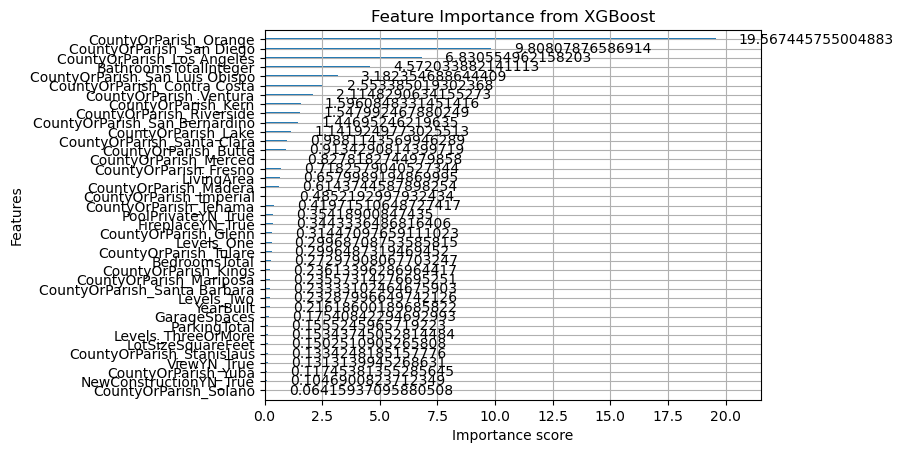

In [288]:
plt.figure(figsize=(30, 20))
plot_importance(model, importance_type='gain')  # You can also use: 'weight', 'cover'
plt.title("Feature Importance from XGBoost")
plt.show()